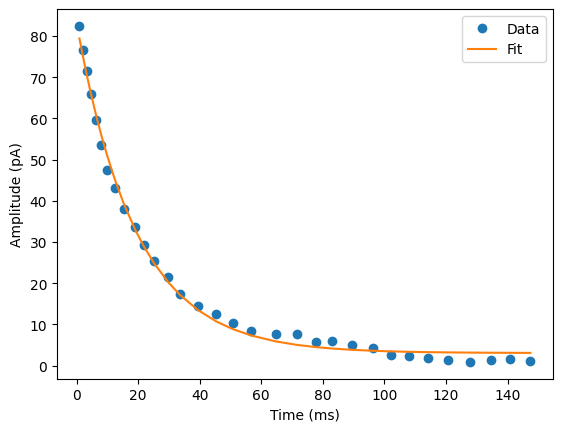

scale: 80.22005963408722 pA
tau: 19.336054191036958 ms
offset: 3.02843851180919 pA


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# data from Sanculi 2019, Fig 16F
raw_data = """
0.9558534806753762, 82.43226566444157
2.0463342121501036, 76.63992819879955
3.3477309698771442, 71.45565714926796
4.5453525551130305, 65.86582150670333
6.417793234980646, 59.561900488023795
8.064172322881017, 53.56369551803445
9.934930162113648, 47.36130588433275
12.43507039883323, 43.18617826891793
15.394065182027251, 37.99349301621136
19.113142985359286, 33.609132215179216
21.946485667807256, 29.33079037415157
25.21848880910977, 25.25326751556628
29.811521848880904, 21.473607449374548
33.63774050597408, 17.29174847141976
39.54002355976888, 14.520670892466484
45.43052672911875, 12.460313008358114
50.77018006394793, 10.30122847366355
56.76950692769394, 8.34184102765468
64.6272507993493, 7.591294104448309
71.4769731306445, 7.65804678296967
77.80613675884892, 5.7985078813036495
82.99826106467717, 5.873674762999954
89.31227912716666, 4.927918326134531
96.39647725360408, 4.181298031076466
102.05755314971671, 2.629718965613975
107.91776518763672, 2.396926011106764
114.1145453525551, 1.8578560610310362
120.64284512256688, 1.3171032703203167
127.94300779716158, 0.873955236439123
134.6738093902507, 1.4489257867280116
140.86049251135915, 1.5190441465193487
147.38542660010094, 1.181354125764308
"""

def convert_data(data):
    lines = data.strip().splitlines()
    return np.array([(float(line.split(",")[0]), float(line.split(",")[1])) for line in lines])

data = convert_data(raw_data)

# plot data, x is time in ms, y is amplitude in pA
if False:
    plt.plot(data[:, 0], data[:, 1])
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (pA)")
    plt.show()

# fit a curve to the data
from scipy.optimize import curve_fit

# define the curve, exponential decay
def curve(x, scale, tau, offset):
    return scale * np.exp(-x / tau) + offset

# fit the curve
curve_fit(curve, data[:, 0], data[:, 1])

# plot the curve
plt.plot(data[:, 0], data[:, 1], marker="o", linestyle="", label="Data")
plt.plot(data[:, 0], curve(data[:, 0], *curve_fit(curve, data[:, 0], data[:, 1])[0]), label="Fit")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (pA)")
plt.legend()
plt.show()

# print the fit parameters
results = curve_fit(curve, data[:, 0], data[:, 1])[0]
print(f"scale: {results[0]} pA")
print(f"tau: {results[1]} ms")
print(f"offset: {results[2]} pA")